# 태양풍 속도 예측 — P9

P7 을 기반으로 **계측기(CV)의 신뢰도**를 먼저 확보하고, 그 위에서 장기 horizon(42h~72h) 개선을 판정한다.
P7 과 마찬가지로 단일 모델이며 앙상블·가중치 적합은 쓰지 않는다.
(시드는 *판정용 CV* 에서만 여러 개 쓰고, 최종 제출 모델은 단일 시드다.)

### P7 대비 변경

| # | 항목 | P7 | P9 |
|---|---|---|---|
| **A** | ablation 사다리 | F 단계가 gather·양방향·속도확장 3개를 동시 변경 | **한 칸에 한 가지만** 바꾸도록 13칸으로 분해 |
| **B** | epoch 선택 | config 마다 자기 곡선의 argmin → 이중 선택 편향 | 곡선 평활 후 **기준 epoch 하나**로 전 config 비교. argmin 은 진단용으로만 표시 |
| **C** | 불확실도 | 폴드 분산만 (`fold_se`) | **시드 3개 × 폴드**의 결합 표준오차. 시드 분산을 따로 보고 |
| **D** | 폴드 구성 | 사슬을 샘플 수 기준 균등 배치 (시간 무관) | **시간 연속 블록**. `forward`(전진 검증) 모드도 선택 가능 |
| **R1** | 탄도 경도 | 중앙자오선 1열만 | `BALLISTIC_LON="all"` — 전 경도 |
| **R2** | 전달 시간 | 고정 상수 (모든 샘플 동일) | **관측 속도 기반 샘플별 τ** + 관측창 이탈 플래그 |
| **S** | 배치 공급 | `DataLoader(num_workers=4)` — 학습 1회마다 워커 재기동 | 전 배열을 GPU 상주시키는 인덱스 배처 |
| **S** | 중단 복구 | 없음 — 중단하면 사다리 전부 재계산 | 칸 단위 `.npy` 저장 → 재실행 시 끝난 칸은 건너뜀 |

### 두 갈래 — 먼저 빠른 A/B, 귀속은 나중에

| | 답하는 질문 | 실행 | 기본값 |
|---|---|---|---|
| **빠른 A/B** | P9 가 P7 보다 나은가 | 2 config x 3폴드 x 2시드 = **12회** | 켬 |
| 전체 사다리 | 13개 변경 중 무엇이 효과였나 | 13 x 3 x 3 = 117회 | `RUN_FULL_LADDER=False` |

제출까지 가는 데 필요한 건 A/B 뿐이다. 사다리는 다음 판을 설계할 때 쓴다.

### 판정 규칙

두 config 은 **같은 폴드·시드**에서 돈다. 그래서 독립 표본이 아니라 **대응 표본**이다.
짝지어 뺀 차이 $d_{f,s}$ 의 표준오차로 판정하면 공통 분산이 상쇄돼
같은 판정력을 훨씬 적은 실행으로 얻는다 (`paired_se` vs `unpaired_se` 를 나란히 출력한다).

$|dCV|$ 가 $2\cdot$`paired_se` 를 넘을 때만 개선/악화로 보고, 그 안이면 `차이없음`.
최종 채택은 표를 보고 **사람이** 결정한다.

> 코로나홀 추출 코드는 P7 과 동일하므로 `CH_CODE_VERSION` 을 그대로 두었다.
> **`work/cache/` 의 P7 캐시가 그대로 재사용된다** (추출에 다시 시간을 쓰지 않는다).

## 1. 설정

In [1]:
from pathlib import Path
import gc, hashlib, json, math, os, random, shutil, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F

SEED = 777
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_ROOT_CANDIDATES = [
    Path(os.getenv("SW_DATA_ROOT", "")) if os.getenv("SW_DATA_ROOT") else None,
    Path("public_dataset/competition_dataset_6h"),
    Path("/home/jovyan/public_dataset/competition_dataset_6h"),
    Path("public/public_dataset/competition_dataset_6h"),
    Path("/home/jovyan/public/public_dataset/competition_dataset_6h"),
    Path("dataset"), Path("/home/jovyan/dataset"),
]
DATA_ROOT = None
for candidate in DATA_ROOT_CANDIDATES:
    if candidate is not None and (candidate / "train/inputs.csv").exists():
        DATA_ROOT = candidate
        break
if DATA_ROOT is None:
    raise FileNotFoundError("데이터 경로 없음")

WORK_DIR = Path("work")
CACHE_ROOT = WORK_DIR / "cache"
OUTPUT_DIR = WORK_DIR / "outputs_p9"
SUBMISSION_DIR = Path("submission")
for directory in (CACHE_ROOT, OUTPUT_DIR, SUBMISSION_DIR):
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_COLUMNS = [f"image_{i:02d}" for i in range(20)]
WIND_COLUMNS = [f"wind_{i:02d}" for i in range(20)]
TARGET_COLUMNS = [f"target_{i:02d}" for i in range(12)]
HORIZONS = np.arange(1, 13) * 6
CHANNELS = ("193", "211")
AU_KM = 1.496e8
LAST_INDEX = 19.0                  # 윈도우 마지막 관측 시점(T0)의 인덱스

# ---- 코로나홀 추출 (P7 과 동일 — 캐시 그대로 재사용) ----------------------
CH_CODE_VERSION = "p7a"
FINE_GRID = (12, 30)
CH_CUTS = (0.30, 0.45, 0.60)
BRIGHT_CUT = 1.60
DISK_MARGIN = 0.95
PER_FRAME_DISK = True

# ---- 사용할 격자 / 레벨 ---------------------------------------------------
CH_GRID = (6, 3)
FOLD_LATITUDE = True
USE_LEVELS = ("dark0.45", "bright")

# ---- 탄도 정렬 ------------------------------------------------------------
REFERENCE_TRANSIT_HOURS = 108.0    # EDA 경험적 최적 지연
TRANSIT_SPEEDS = (315.0, 345.0, 385.0, 435.0, 500.0, 600.0)   # 고정 모드에서만 사용
BALLISTIC_OFFSETS = (-4, -2, 0, 2)         # 탄도창 샘플 시점 (6h 스텝)
GATHER_OFFSETS = (-6, -4, -2, 0, 2, 6)     # 적응형 gather 샘플 시점
BALLISTIC_SOURCE = "window"        # "window" = 기준 τ ± offset / "speeds" = 속도별 점 샘플
BALLISTIC_LAT = "profile"          # "profile" = 위도 전부 / "equator" = 적도 1행
BALLISTIC_LON = "all"              # [R1] "all" = 경도 전부 / "central" = 중앙자오선 1열
USE_BALLISTIC_WINDOW = True

# ---- [R2] 적응형 전달 시간 ------------------------------------------------
ADAPTIVE_AREA = True               # 탄도창 인덱스를 샘플별 관측 속도로
ADAPTIVE_GATHER = True             # gather 인덱스를 샘플별 관측 속도로
USE_TRANSIT_FLAGS = True           # 관측창 이탈 플래그를 head 에 투입
SPEED_FLOOR, SPEED_CEIL = 280.0, 800.0
FLAG_DIM = 4                       # (미래이탈, 과거이탈, 이탈량+, 이탈량-)

# ---- 모델 -----------------------------------------------------------------
USE_CH_GATHER = True
CH_HIDDEN = 64
CH_BIDIRECTIONAL = True
GATHER_DIM = 16
HORIZON_EMBED = 8
DROPOUT = 0.4
VERBOSE_MODEL = True

# ---- 학습 -----------------------------------------------------------------
BATCH_SIZE = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-3
GRAD_CLIP = 1.0
LOSS_EPSILON = 1e-8
LOSS_SCALE = 100.0
CV_EPOCHS = 30
AUGMENT = True
AUG_CH_NOISE = 0.05

# ---- 배치 공급 -------------------------------------------------------------
# 데이터가 전부 메모리 위 numpy 배열이라 I/O 가 없다. torch DataLoader 는
# train_run 호출마다 워커 프로세스를 새로 띄워서, 이 규모에서는 학습보다 오버헤드가 크다.
# 전 배열을 DEVICE 에 한 번 올려두고 인덱스 슬라이스로 배치를 만든다.
BATCHER_LIMIT_MB = 3000    # 이보다 크면 CPU 에 두고 배치마다 옮긴다

# ---- [C][D] 계측기 --------------------------------------------------------
RUN_FULL_LADDER = False   # 기본은 빠른 A/B 만. 귀속(어느 변경이 효과였나)이 필요할 때 True
QUICK_SEEDS = (777, 778)  # 대응 비교라 2개로 충분하다 (아래 설명)
N_FOLDS = 5
FOLD_MODE = "block"       # [D] "block"=시간 연속 블록 / "balanced"=P7 / "forward"=전진 검증
CV_SEEDS = (777, 778, 779)     # [C] 전체 사다리용 시드
LADDER_FOLDS = 3          # 사다리는 앞 3폴드만 (시간 절약). 확정 검증은 전 폴드
EPOCH_SMOOTH = 3          # [B] epoch 곡선 이동평균 창
NOISE_SIGMA = 2.0         # [C] 판정 임계 = NOISE_SIGMA * 결합 표준오차

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

print("PyTorch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("data:", DATA_ROOT.resolve())

PyTorch: 2.5.1+cu124 | device: cuda
GPU: NVIDIA A100-SXM4-40GB
data: /home/jovyan/public_dataset/competition_dataset_6h


## 2. 데이터 로드 · 시간축 복원

P7 과 동일하다. `inputs.csv` 에 타임스탬프가 없고 행 순서도 시간 순서가 아니므로,
한 행의 `image_00..image_19` 가 연속 20시점이라는 사실만으로 프레임 사슬을 복원한다.

**P9 에서 이 사슬의 역할이 하나 늘었다.** P7 에서는 "폴드 경계"였지만,
P9 의 `FOLD_MODE="block"` 에서는 **사슬 순서가 곧 시간 순서**라는 가정 위에서 폴드를 자른다.
아래 셀 마지막에서 그 가정을 파일명 정렬로 점검한다.

In [2]:
train_inputs = pd.read_csv(DATA_ROOT / "train/inputs.csv")
train_targets_frame = pd.read_csv(DATA_ROOT / "train/targets.csv")
val_inputs = pd.read_csv(DATA_ROOT / "validation/inputs.csv")
val_targets_frame = pd.read_csv(DATA_ROOT / "validation/targets.csv")
test_inputs = pd.read_csv(DATA_ROOT / "test/inputs.csv")
assert train_inputs.sample_id.tolist() == train_targets_frame.sample_id.tolist()
assert val_inputs.sample_id.tolist() == val_targets_frame.sample_id.tolist()


def fill_wind(inputs):
    wind = inputs[WIND_COLUMNS].to_numpy(np.float64)
    valid = np.isfinite(wind).astype(np.float32)
    frame = pd.DataFrame(wind).ffill(axis=1).bfill(axis=1)
    filled = frame.to_numpy(np.float32)
    return np.nan_to_num(filled, nan=float(np.nanmedian(wind))), valid


train_wind, train_wind_valid = fill_wind(train_inputs)
val_wind, val_wind_valid = fill_wind(val_inputs)
test_wind, test_wind_valid = fill_wind(test_inputs)
train_targets = train_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)
val_targets = val_targets_frame[TARGET_COLUMNS].to_numpy(np.float32)


def reconstruct_frame_chains(inputs):
    """이미지 파일명만으로 프레임 시간축을 복원한다. 행 순서에 의존하지 않는다."""
    images = inputs[IMAGE_COLUMNS].to_numpy()
    successor, predecessor, conflicts = {}, {}, 0
    for row in images:
        for current, following in zip(row[:-1], row[1:]):
            if successor.setdefault(current, following) != following:
                conflicts += 1
            if predecessor.setdefault(following, current) != current:
                conflicts += 1
    names = set(images.ravel().tolist())
    chains, visited = [], set()
    for head in sorted(names - set(predecessor)):
        chain, node = [], head
        while node is not None and node not in visited:
            visited.add(node); chain.append(node); node = successor.get(node)
        chains.append(chain)
    assert conflicts == 0 and not (names - visited), "사슬 복원 실패"
    return chains


def sample_chain_index(inputs, chains):
    position = {name: (c, o)
                for c, chain in enumerate(chains) for o, name in enumerate(chain)}
    first = inputs[IMAGE_COLUMNS[0]].to_numpy()
    chain_id = np.array([position[n][0] for n in first])
    offset = np.array([position[n][1] for n in first])
    return chain_id, offset


TRAIN_CHAINS = reconstruct_frame_chains(train_inputs)
VAL_CHAINS = reconstruct_frame_chains(val_inputs)
TEST_CHAINS = reconstruct_frame_chains(test_inputs)
TRAIN_CHAIN_ID, TRAIN_OFFSET = sample_chain_index(train_inputs, TRAIN_CHAINS)

train_files = [n for chain in TRAIN_CHAINS for n in chain]
val_files = [n for chain in VAL_CHAINS for n in chain]
test_files = [n for chain in TEST_CHAINS for n in chain]
train_map = {n: i for i, n in enumerate(train_files)}
val_map = {n: i for i, n in enumerate(val_files)}
test_map = {n: i for i, n in enumerate(test_files)}

print(f"train {len(train_inputs):,} 샘플 / 사슬 {len(TRAIN_CHAINS)}개 / 고유 이미지 {len(train_files):,}")
print(f"val   {len(val_inputs):,} 샘플 / 사슬 {len(VAL_CHAINS)}개 / 고유 이미지 {len(val_files):,}")
print(f"test  {len(test_inputs):,} 샘플 / 사슬 {len(TEST_CHAINS)}개 / 고유 이미지 {len(test_files):,}")
print(f"\ntrain 사슬별 샘플 수: {np.bincount(TRAIN_CHAIN_ID).tolist()}")

# --- [D] 사슬 순서 == 시간 순서 가정 점검 ---------------------------------
heads = [chain[0] for chain in TRAIN_CHAINS]
CHAIN_ORDER_IS_TIME = heads == sorted(heads)
print(f"\n[D] 사슬 머리 파일명이 정렬 순서인가: {CHAIN_ORDER_IS_TIME}")
if not CHAIN_ORDER_IS_TIME:
    print("    -> 파일명이 시간 인코딩이 아닐 수 있다. FOLD_MODE='block' 의 시간 가정을 확인할 것.")
print("    사슬 머리 5개:", heads[:5])
print("    사슬 꼬리 5개:", [chain[-1] for chain in TRAIN_CHAINS][-5:])

train 9,607 샘플 / 사슬 28개 / 고유 이미지 10,139
val   1,199 샘플 / 사슬 11개 / 고유 이미지 1,408
test  3,868 샘플 / 사슬 13개 / 고유 이미지 4,115

train 사슬별 샘플 수: [629, 96, 961, 564, 285, 251, 169, 792, 578, 528, 149, 316, 100, 363, 14, 316, 232, 76, 747, 173, 161, 108, 138, 54, 161, 33, 961, 652]

[D] 사슬 머리 파일명이 정렬 순서인가: True
    사슬 머리 5개: ['image_000913.png', 'image_001424.png', 'image_001512.png', 'image_001602.png', 'image_001739.png']
    사슬 꼬리 5개: ['image_002569.png', 'image_005859.png', 'image_007913.png', 'image_009995.png', 'image_009770.png']


## 3. 코로나홀 추출

**P7 과 완전히 동일하다.** `CH_CODE_VERSION` 을 그대로 두었으므로 P7 이 만든 캐시가 재사용된다.
(추출 로직을 손대면 반드시 이 값을 올릴 것.)

In [3]:
FINE_LAT, FINE_LON = FINE_GRID
FINE_CELLS = FINE_LAT * FINE_LON
N_LEVELS = len(CH_CUTS) + 1
LEVEL_NAMES = [f"dark{c}" for c in CH_CUTS] + ["bright"]


def load_pair(split, name):
    planes = []
    for channel in CHANNELS:
        with Image.open(DATA_ROOT / split / channel / name) as image:
            planes.append(np.asarray(image.convert("L"), dtype=np.float32))
    return np.stack(planes)


def detect_disk(frame):
    """플레어에 둔감한 원반 검출. 배경과 원반 내부의 중간값을 임계로 쓴다."""
    plane = frame.mean(axis=0)
    background = np.percentile(plane, 2.0)
    interior = np.percentile(plane, 70.0)
    mask = plane > background + 0.35 * (interior - background)
    ys, xs = np.nonzero(mask)
    return float(ys.mean()), float(xs.mean()), float(math.sqrt(mask.sum() / math.pi))


_geometry_cache = {}
GEOMETRY_CACHE_LIMIT = 96


def cell_geometry(side, center_y, center_x, radius):
    key = (side, round(center_y), round(center_x), round(radius))
    entry = _geometry_cache.get(key)
    if entry is None:
        _, cy, cx, r = key
        grid_y, grid_x = np.mgrid[0:side, 0:side].astype(np.float32)
        disk = np.sqrt((grid_y - cy) ** 2 + (grid_x - cx) ** 2) <= r
        lat = np.clip((grid_y - (cy - r)) / (2 * r) * FINE_LAT, 0, FINE_LAT - 1e-4)
        lon = np.clip((grid_x - (cx - r)) / (2 * r) * FINE_LON, 0, FINE_LON - 1e-4)
        cell = (lat.astype(np.int32) * FINE_LON + lon.astype(np.int32))[disk]
        entry = (disk, cell)
        _geometry_cache[key] = entry
        while len(_geometry_cache) > GEOMETRY_CACHE_LIMIT:
            _geometry_cache.pop(next(iter(_geometry_cache)))
    return entry


def extract_split(split, filenames):
    area = np.zeros((len(filenames), N_LEVELS, FINE_CELLS), np.float32)
    geometry = np.zeros((len(filenames), 4), np.float32)
    fixed = None
    if not PER_FRAME_DISK:
        sample = np.unique(np.linspace(0, len(filenames) - 1, 200).astype(int))
        measured = np.array([detect_disk(load_pair(split, filenames[i])) for i in sample])
        fixed = tuple(np.median(measured, axis=0))
    started = time.perf_counter()
    for index, name in enumerate(filenames):
        frame = load_pair(split, name)
        center_y, center_x, radius = fixed if fixed is not None else detect_disk(frame)
        disk, cell = cell_geometry(frame.shape[-1], center_y, center_x, radius * DISK_MARGIN)
        on_disk = frame[:, disk]
        total = max(on_disk.shape[1], 1)
        geometry[index] = (center_y, center_x, radius, total)
        median = np.median(on_disk[:, ::4], axis=1, keepdims=True)
        normalized = on_disk / np.maximum(median, 1e-3)
        for level, cut in enumerate(CH_CUTS):
            selection = np.logical_and(normalized[0] <= cut, normalized[1] <= cut)
            area[index, level] = np.bincount(cell[selection], minlength=FINE_CELLS) / total
        selection = np.logical_and(normalized[0] >= BRIGHT_CUT, normalized[1] >= BRIGHT_CUT)
        area[index, -1] = np.bincount(cell[selection], minlength=FINE_CELLS) / total
        if (index + 1) % 2000 == 0 or index + 1 == len(filenames):
            print(f"  {split} {index + 1}/{len(filenames)} "
                  f"({time.perf_counter() - started:.0f}s)", flush=True)
    return area, geometry


def cached_extract(split, filenames):
    tag = (f"{CH_CODE_VERSION}_{FINE_LAT}x{FINE_LON}"
           f"_c{'-'.join(str(c) for c in CH_CUTS)}_b{BRIGHT_CUT}_m{DISK_MARGIN}"
           f"_{'perframe' if PER_FRAME_DISK else 'fixed'}")
    area_path = CACHE_ROOT / f"ch_{split}_{tag}.npy"
    geometry_path = CACHE_ROOT / f"geom_{split}_{tag}.npy"
    if area_path.exists() and geometry_path.exists():
        area = np.load(area_path)
        if area.shape == (len(filenames), N_LEVELS, FINE_CELLS):
            print(f"캐시 재사용: {area_path.name}")
            return area, np.load(geometry_path)
    area, geometry = extract_split(split, filenames)
    np.save(area_path, area); np.save(geometry_path, geometry)
    return area, geometry


train_area, train_geometry = cached_extract("train", train_files)
val_area, val_geometry = cached_extract("validation", val_files)
test_area, test_geometry = cached_extract("test", test_files)

for name, geometry in [("train", train_geometry), ("val", val_geometry), ("test", test_geometry)]:
    radius = geometry[:, 2]
    print(f"{name:5s} 반지름 {radius.mean():.1f} ± {radius.std():.1f}px "
          f"({radius.std()/radius.mean():.2%}), 원반 픽셀 {geometry[:, 3].mean():,.0f}")

캐시 재사용: ch_train_p7a_12x30_c0.3-0.45-0.6_b1.6_m0.95_perframe.npy
캐시 재사용: ch_validation_p7a_12x30_c0.3-0.45-0.6_b1.6_m0.95_perframe.npy
캐시 재사용: ch_test_p7a_12x30_c0.3-0.45-0.6_b1.6_m0.95_perframe.npy
train 반지름 228.7 ± 10.7px (4.68%), 원반 픽셀 148,544
val   반지름 227.7 ± 10.6px (4.67%), 원반 픽셀 147,313
test  반지름 231.3 ± 11.2px (4.83%), 원반 픽셀 151,982


## 4. 격자 집계 · 탄도 정렬 — **[R1] 경도 확장 · [R2] 적응형 전달 시간**

### [R2] 적응형 전달 시간

P7 은 모든 샘플에 같은 지연 108h 를 적용했다. 108h 는 **모집단 평균**이고,
고속 스트림 샘플의 실제 전달 시간은 70h 아래로 떨어진다.

관측된 최근 4스텝 평균 속도 $\hat v$ 로 샘플별 지연을 만든다.

$$\hat\tau_i = \mathrm{TAU\_SCALE}\cdot\frac{1\,\mathrm{AU}}{\hat v_i},\qquad
\mathrm{TAU\_SCALE}=\frac{108\,\mathrm{h}}{1\mathrm{AU}/\bar v_{\text{train}}}$$

`TAU_SCALE` 은 **train 평균 속도에서 정확히 108h 가 되도록** 맞춘 보정 계수다.
EDA 의 경험적 최적을 유지한 채 샘플별로만 흔든다.

인덱스는 $\mathrm{idx}_{i,h} = 19 + (6h - \hat\tau_i)/6$ 이고, $[0,19]$ 밖으로 나가면 clip 한다.

### [R2] 관측창 이탈 플래그

**고정 τ 에서는 clip 여부가 horizon 만의 함수라 horizon embedding 과 중복이어서 무의미했다.**
적응형이 되면 같은 horizon 이라도 샘플마다 clip 여부가 달라지므로 비로소 정보가 된다.
`(미래이탈 여부, 과거이탈 여부, 이탈량+, 이탈량-)` 4개를 head 에 직접 넣는다.

### [R1] 탄도 경도 확장

`BALLISTIC_LON="all"` 이면 위도 프로파일 × **전 경도**를 뽑는다.
gather 경로(양방향 GRU 은닉)는 시퀀스 전체를 섞은 값이라 시간 국소성이 흐려지는데,
원시 셀 값을 소스 시각에서 직접 뽑으면 날카로운 신호가 하나 더 들어간다.

In [4]:
def aggregate(area, grid_lat, grid_lon, fold):
    """(n, L, FINE_CELLS) -> (n, L, cells). 면적이 원반 대비 비율이라 단순 합이 정확하다."""
    block = area.reshape(len(area), N_LEVELS, FINE_LAT, FINE_LON)
    block = block.reshape(len(area), N_LEVELS, grid_lat, FINE_LAT // grid_lat,
                          grid_lon, FINE_LON // grid_lon).sum(axis=(3, 5))
    if fold:
        block = block + block[:, :, ::-1, :]
        block = block[:, :, : (grid_lat + 1) // 2, :]
    return np.ascontiguousarray(block.reshape(len(area), N_LEVELS, -1), dtype=np.float32)


def image_index_matrix(inputs, image_map):
    return np.asarray([[image_map[n] for n in row]
                       for row in inputs[IMAGE_COLUMNS].itertuples(index=False, name=None)],
                      dtype=np.int64)


train_index_matrix = image_index_matrix(train_inputs, train_map)
val_index_matrix = image_index_matrix(val_inputs, val_map)
test_index_matrix = image_index_matrix(test_inputs, test_map)

# TAU_SCALE 은 train 전용 스칼라. EDA 의 108h 를 train 평균 속도에 고정시킨다.
TAU_REF_SPEED = float(train_wind.mean())
TAU_SCALE = REFERENCE_TRANSIT_HOURS / (AU_KM / TAU_REF_SPEED / 3600.0)
print(f"[R2] train 평균 속도 {TAU_REF_SPEED:.1f} km/s -> 순수 전달시간 "
      f"{AU_KM / TAU_REF_SPEED / 3600.0:.1f}h, TAU_SCALE={TAU_SCALE:.3f} "
      f"(보정 후 {REFERENCE_TRANSIT_HOURS:.0f}h)")


def estimate_tau(wind):
    """샘플별 전달 지연(시간). (n,)"""
    speed = np.clip(wind[:, -4:].mean(axis=1), SPEED_FLOOR, SPEED_CEIL)
    return TAU_SCALE * AU_KM / speed / 3600.0


def reference_index_raw(wind, adaptive):
    """클리핑 전 기준 인덱스. (n, 12)"""
    tau = estimate_tau(wind) if adaptive else np.full(len(wind), REFERENCE_TRANSIT_HOURS)
    return LAST_INDEX + (HORIZONS[None, :] - tau[:, None]) / 6.0


def offset_indices(wind, offsets, adaptive):
    """기준 인덱스에 오프셋을 더해 클리핑. (n, 12, K)"""
    raw = reference_index_raw(wind, adaptive)[:, :, None] \
        + np.asarray(offsets, np.float64)[None, None, :]
    return np.clip(raw, 0.0, LAST_INDEX).astype(np.float32)


def fixed_speed_indices(n_samples, speeds):
    """P3/P7 방식: 고정 속도별 점 샘플. (n, 12, S)"""
    table = np.zeros((12, len(speeds)), np.float64)
    for h in range(12):
        for s, speed in enumerate(speeds):
            table[h, s] = np.clip(
                LAST_INDEX + ((h + 1) * 6.0 - AU_KM / speed / 3600.0) / 6.0,
                0.0, LAST_INDEX)
    return np.repeat(table[None].astype(np.float32), n_samples, axis=0)


def area_indices(wind):
    if BALLISTIC_SOURCE == "window":
        return offset_indices(wind, BALLISTIC_OFFSETS, ADAPTIVE_AREA)
    return fixed_speed_indices(len(wind), TRANSIT_SPEEDS)


def gather_indices(wind):
    if ADAPTIVE_GATHER:
        return offset_indices(wind, GATHER_OFFSETS, True)
    return fixed_speed_indices(len(wind), TRANSIT_SPEEDS)


def transit_flags(wind):
    """[R2] 관측창 이탈 플래그. (n, 12, FLAG_DIM)"""
    raw = reference_index_raw(wind, ADAPTIVE_AREA)
    over = np.clip(raw - LAST_INDEX, 0.0, None) / 8.0
    under = np.clip(-raw, 0.0, None) / 8.0
    return np.stack([(raw > LAST_INDEX).astype(np.float32),
                     (raw < 0.0).astype(np.float32),
                     over.astype(np.float32),
                     under.astype(np.float32)], axis=2).astype(np.float32)


def pick_per_sample(sequence, index):
    """sequence (n, 20, D) 를 샘플별 실수 인덱스 index (n, K) 에서 선형보간. -> (n, K, D)"""
    lower = np.floor(index).astype(np.int64)
    upper = np.minimum(lower + 1, int(LAST_INDEX))
    weight = (index - lower).astype(np.float32)[:, :, None]
    rows = np.arange(len(sequence))[:, None]
    return sequence[rows, lower] * (1.0 - weight) + sequence[rows, upper] * weight


def flatten_ch(grid, indexes):
    return grid[indexes].reshape(len(indexes), 20, N_USED_LEVELS * N_CELLS).astype(np.float32)


def ballistic_columns():
    """[R1] 탄도 샘플에 쓸 셀 번호."""
    lons = list(range(GRID_LON)) if BALLISTIC_LON == "all" else [CENTRAL_LON]
    return [lat * GRID_LON + lon for lat in AREA_LAT_ROWS for lon in lons], len(lons)


def ballistic_area(grid, indexes, index):
    """탄도 소스 시각의 코로나홀 면적. index (n, 12, K) -> (n, 12, K*D)"""
    columns, _ = ballistic_columns()
    sequence = grid[indexes][:, :, :, columns]
    sequence = sequence.reshape(len(indexes), 20, -1)
    n_samples, n_horizon, n_offset = index.shape
    picked = pick_per_sample(sequence, index.reshape(n_samples, n_horizon * n_offset))
    return picked.reshape(n_samples, n_horizon, -1).astype(np.float32)


def build_ballistic(grid, indexes, wind):
    return ballistic_area(grid, indexes, area_indices(wind))


def configure(**overrides):
    """설정을 바꾸고 파생 상수를 다시 만든다. ablation 은 이 함수로만 한다."""
    globals().update(overrides)
    global GRID_LAT, GRID_LON, USED_LAT, N_CELLS, CENTRAL_LON, EQUATOR_ROW
    global LEVEL_INDEX, N_USED_LEVELS, CH_SEQ_DIM
    global train_grid, val_grid, test_grid
    global AREA_LAT_ROWS, N_AREA_OFFSETS, BALLISTIC_DIM, N_GATHER

    GRID_LAT, GRID_LON = CH_GRID
    assert FINE_LAT % GRID_LAT == 0 and FINE_LON % GRID_LON == 0
    USED_LAT = (GRID_LAT + 1) // 2 if FOLD_LATITUDE else GRID_LAT
    N_CELLS = USED_LAT * GRID_LON
    CENTRAL_LON = GRID_LON // 2
    EQUATOR_ROW = USED_LAT - 1 if FOLD_LATITUDE else GRID_LAT // 2
    LEVEL_INDEX = [LEVEL_NAMES.index(name) for name in USE_LEVELS]
    N_USED_LEVELS = len(LEVEL_INDEX)
    CH_SEQ_DIM = N_USED_LEVELS * N_CELLS

    train_grid = aggregate(train_area, GRID_LAT, GRID_LON, FOLD_LATITUDE)[:, LEVEL_INDEX]
    val_grid = aggregate(val_area, GRID_LAT, GRID_LON, FOLD_LATITUDE)[:, LEVEL_INDEX]
    test_grid = aggregate(test_area, GRID_LAT, GRID_LON, FOLD_LATITUDE)[:, LEVEL_INDEX]

    AREA_LAT_ROWS = list(range(USED_LAT)) if BALLISTIC_LAT == "profile" else [EQUATOR_ROW]
    N_AREA_OFFSETS = (len(BALLISTIC_OFFSETS) if BALLISTIC_SOURCE == "window"
                      else len(TRANSIT_SPEEDS))
    _, n_lons = ballistic_columns()
    BALLISTIC_DIM = N_AREA_OFFSETS * len(AREA_LAT_ROWS) * n_lons * N_USED_LEVELS
    N_GATHER = len(GATHER_OFFSETS) if ADAPTIVE_GATHER else len(TRANSIT_SPEEDS)


configure()
print(f"\n격자 {GRID_LAT}x{GRID_LON} -> 셀 {N_CELLS} (적도 대칭 접기 {FOLD_LATITUDE}), 레벨 {USE_LEVELS}")
print(f"ch_seq {CH_SEQ_DIM} / 탄도 {BALLISTIC_DIM} (경도 {BALLISTIC_LON}) / "
      f"gather {N_GATHER} / 플래그 {FLAG_DIM if USE_TRANSIT_FLAGS else 0}")

_tau = estimate_tau(train_wind)
print(f"\n[R2] 샘플별 전달 지연 분포: {np.percentile(_tau, [5, 25, 50, 75, 95]).round(1)} h "
      f"(5/25/50/75/95%)  — P7 은 전 샘플 {REFERENCE_TRANSIT_HOURS:.0f}h 고정")
_raw = reference_index_raw(train_wind, True)
print(f"[R2] 관측창 이탈 비율 (idx>19): "
      f"{[f'{h}h {(_raw[:, i] > LAST_INDEX).mean():.1%}' for i, h in enumerate(HORIZONS)][6:]}")
print("\n[R2] 기준 인덱스 분위수 (19 = 마지막 관측)")
print(pd.DataFrame(np.percentile(np.clip(_raw, 0, LAST_INDEX), [10, 50, 90], axis=0).T,
                   index=[f"{h}h" for h in HORIZONS], columns=["p10", "p50", "p90"]).round(2))

[R2] train 평균 속도 414.6 km/s -> 순수 전달시간 100.2h, TAU_SCALE=1.077 (보정 후 108h)

격자 6x3 -> 셀 9 (적도 대칭 접기 True), 레벨 ('dark0.45', 'bright')
ch_seq 18 / 탄도 72 (경도 all) / gather 6 / 플래그 4

[R2] 샘플별 전달 지연 분포: [ 75.6  97.  113.2 128.1 144.9] h (5/25/50/75/95%)  — P7 은 전 샘플 108h 고정
[R2] 관측창 이탈 비율 (idx>19): ['42h 0.0%', '48h 0.0%', '54h 0.0%', '60h 0.0%', '66h 0.7%', '72h 3.1%']

[R2] 기준 인덱스 분위수 (19 = 마지막 관측)
      p10    p50    p90
6h   0.00   1.13   6.21
12h  0.00   2.13   7.21
18h  0.00   3.13   8.21
24h  0.00   4.13   9.21
30h  0.75   5.13  10.21
36h  1.75   6.13  11.21
42h  2.75   7.13  12.21
48h  3.75   8.13  13.21
54h  4.75   9.13  14.21
60h  5.75  10.13  15.21
66h  6.75  11.13  16.21
72h  7.75  12.13  17.21


## 5. 정규화 통계 · Dataset

CV 폴드마다 **그 폴드의 학습 행에서만** 통계를 다시 낸다. 최종 학습에서는 train 전체를 쓴다.

Dataset 이 `gather_idx` 와 `flags` 를 함께 실어 보낸다 — 적응형 인덱스는 샘플마다 다르므로
모델 버퍼에 상수로 넣을 수 없다.

**CH 노이즈 증강을 곱셈에서 덧셈으로 바꿨다.** 표준화된 값에 곱셈 노이즈를 주면
평균 근처 셀은 노이즈가 0, 극단값 셀은 최대가 되어 의도와 반대로 작동한다.

In [5]:
STAT_NAMES = ["last", "mean4", "mean", "std", "min", "max", "slope", "last_minus_mean4", "range"]
NUM_STATS = len(STAT_NAMES)
_TIME_CENTERED = np.arange(20, dtype=np.float32) - 9.5
_TIME_DENOM = float((_TIME_CENTERED ** 2).sum())


def build_wind_stats(wind):
    last = wind[:, -1]
    mean4 = wind[:, -4:].mean(axis=1)
    slope = (wind - wind.mean(axis=1, keepdims=True)) @ _TIME_CENTERED / _TIME_DENOM
    return np.stack([last, mean4, wind.mean(axis=1), wind.std(axis=1), wind.min(axis=1),
                     wind.max(axis=1), slope, last - mean4,
                     wind.max(axis=1) - wind.min(axis=1)], axis=1).astype(np.float32)


def fit_stats(rows):
    """주어진 train 행에서만 정규화/복원 통계를 산출한다."""
    wind = train_wind[rows]
    targets = train_targets[rows]
    ch_seq = flatten_ch(train_grid, train_index_matrix[rows]).reshape(-1, CH_SEQ_DIM)
    ballistic = build_ballistic(train_grid, train_index_matrix[rows], wind
                                ).reshape(-1, BALLISTIC_DIM)
    statistics = build_wind_stats(wind)
    residual = targets - wind[:, -1:]
    return {
        "wind_mean": float(wind.mean()), "wind_std": float(wind.std() + 1e-6),
        "diff_std": float(np.diff(wind, axis=1, prepend=wind[:, :1]).std() + 1e-6),
        "stats_mean": statistics.mean(axis=0), "stats_std": statistics.std(axis=0) + 1e-6,
        "ch_mean": ch_seq.mean(axis=0), "ch_std": ch_seq.std(axis=0) + 1e-8,
        "ballistic_mean": ballistic.mean(axis=0), "ballistic_std": ballistic.std(axis=0) + 1e-8,
        "residual_mean": residual.mean(axis=0), "residual_std": residual.std(axis=0) + 1e-6,
        "clip_low": float(targets.min() * 0.95), "clip_high": float(targets.max() * 1.05),
        "target_mean": targets.mean(axis=0),
    }


BATCH_KEYS = ("wind_seq", "wind_stats", "ch_seq", "ballistic",
              "gather_idx", "flags", "last_wind")


def build_arrays(inputs, index_matrix, wind, wind_valid, grid, stats, targets=None):
    """모델 입력 배열 일체를 만든다 (numpy)."""
    arrays = {
        "wind_seq": np.stack([
            (wind - stats["wind_mean"]) / stats["wind_std"],
            np.diff(wind, axis=1, prepend=wind[:, :1]) / stats["diff_std"],
            wind_valid], axis=2).astype(np.float32),
        "wind_stats": ((build_wind_stats(wind) - stats["stats_mean"])
                       / stats["stats_std"]).astype(np.float32),
        "ch_seq": ((flatten_ch(grid, index_matrix) - stats["ch_mean"])
                   / stats["ch_std"]).astype(np.float32),
        "ballistic": ((build_ballistic(grid, index_matrix, wind) - stats["ballistic_mean"])
                      / stats["ballistic_std"]).astype(np.float32),
        "gather_idx": gather_indices(wind),
        "flags": transit_flags(wind),
        "last_wind": np.ascontiguousarray(wind[:, -1]).astype(np.float32),
    }
    if targets is not None:
        arrays["target"] = targets.astype(np.float32)
    arrays["sample_ids"] = inputs.sample_id.to_numpy()
    return arrays


class Batcher:
    """배열을 한 번만 텐서로 올려두고 인덱스 슬라이스로 배치를 낸다.

    증강(CH 노이즈)은 배치마다 GPU 에서 더한다 — 표준화된 값이므로 덧셈이 맞다
    (P7 은 곱셈이라 평균 근처 셀은 노이즈 0, 극단값 셀만 흔들려 방향이 반대였다).
    """

    def __init__(self, arrays, shuffle=False, seed=SEED, training=False):
        self.keys = [k for k in BATCH_KEYS + ("target",) if k in arrays]
        total_mb = sum(arrays[k].nbytes for k in self.keys) / 1024 ** 2
        self.device = DEVICE if total_mb <= BATCHER_LIMIT_MB else torch.device("cpu")
        self.tensors = {k: torch.as_tensor(arrays[k]).to(self.device) for k in self.keys}
        self.sample_ids = arrays["sample_ids"]
        self.count = len(self.sample_ids)
        self.shuffle = shuffle
        self.training = training
        self.generator = torch.Generator().manual_seed(seed)
        self.megabytes = total_mb

    def __len__(self):
        return (self.count + BATCH_SIZE - 1) // BATCH_SIZE

    def __iter__(self):
        order = (torch.randperm(self.count, generator=self.generator) if self.shuffle
                 else torch.arange(self.count))
        order = order.to(self.device)
        for start in range(0, self.count, BATCH_SIZE):
            selection = order[start:start + BATCH_SIZE]
            batch = {k: v.index_select(0, selection) for k, v in self.tensors.items()}
            if self.training and AUGMENT and AUG_CH_NOISE > 0:
                for key in ("ch_seq", "ballistic"):
                    batch[key] = batch[key] + torch.randn(
                        batch[key].shape, device=self.device) * AUG_CH_NOISE
            yield batch

    def release(self):
        self.tensors.clear()


def make_batcher(inputs, index_matrix, wind, wind_valid, grid, stats, targets=None,
                 shuffle=False, seed=SEED, training=False):
    arrays = build_arrays(inputs, index_matrix, wind, wind_valid, grid, stats, targets)
    return Batcher(arrays, shuffle=shuffle, seed=seed, training=training)


_probe_stats = fit_stats(np.arange(len(train_inputs)))
_probe_batcher = make_batcher(train_inputs, train_index_matrix, train_wind, train_wind_valid,
                              train_grid, _probe_stats, train_targets, shuffle=True)
print(f"입력 배열 {_probe_batcher.megabytes:,.0f} MB -> {_probe_batcher.device} 상주, "
      f"배치 {len(_probe_batcher)}개")
_probe_batcher.release(); del _probe_batcher; gc.collect()

입력 배열 52 MB -> cuda 상주, 배치 151개


0

## 6. 모델

P7 과 구조는 같고 **입력 두 가지가 늘었다.**

- `gather_idx` — 샘플별 gather 인덱스. 모델 버퍼가 아니라 배치로 들어온다 ([R2])
- `flags` — 관측창 이탈 플래그 ([R2])

head 는 12 horizon 에 **가중치를 공유**한다. horizon 을 구분하는 것은
embedding · 탄도창 · gather · 플래그다.

In [6]:
class SolarWindP9(nn.Module):
    def __init__(self, stats):
        super().__init__()
        self.wind_gru = nn.GRU(3, 96, num_layers=2, batch_first=True)
        self.stats_encoder = nn.Sequential(
            nn.Linear(NUM_STATS, 128), nn.SELU(inplace=True),
            nn.Linear(128, 64), nn.SELU(inplace=True))
        shared_dim = 96 + 64

        self.ch_gru = nn.GRU(CH_SEQ_DIM, CH_HIDDEN, num_layers=2, batch_first=True,
                             bidirectional=CH_BIDIRECTIONAL)
        directions = 2 if CH_BIDIRECTIONAL else 1
        self.ch_dropout = nn.Dropout(DROPOUT)
        shared_dim += CH_HIDDEN * directions

        head_extra = 0
        if USE_CH_GATHER:
            self.gather_project = nn.Sequential(
                nn.Linear(CH_HIDDEN * directions, GATHER_DIM), nn.ReLU(inplace=True))
            head_extra += GATHER_DIM * N_GATHER
        if USE_BALLISTIC_WINDOW:
            head_extra += BALLISTIC_DIM
        if USE_TRANSIT_FLAGS:
            head_extra += FLAG_DIM

        self.horizon_embedding = nn.Parameter(torch.randn(12, HORIZON_EMBED) * 0.1)
        head_input = shared_dim + HORIZON_EMBED + head_extra
        self.head = nn.Sequential(
            nn.Linear(head_input, 192), nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(192, 96), nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(96, 1))

        self.register_buffer("residual_mean", torch.as_tensor(stats["residual_mean"]))
        self.register_buffer("residual_std", torch.as_tensor(stats["residual_std"]))
        if VERBOSE_MODEL:
            print(f"shared={shared_dim} head_input={head_input} "
                  f"(gather {GATHER_DIM * N_GATHER if USE_CH_GATHER else 0}, "
                  f"ballistic {BALLISTIC_DIM if USE_BALLISTIC_WINDOW else 0}, "
                  f"flags {FLAG_DIM if USE_TRANSIT_FLAGS else 0})")

    @staticmethod
    def _gather(projected, index):
        """projected (B, 20, G) 를 샘플별 실수 인덱스 index (B, H, S) 에서 선형보간."""
        batch, horizon, offsets = index.shape
        width = projected.shape[-1]
        lower = index.floor().clamp(0, LAST_INDEX)
        weight = (index - lower).unsqueeze(-1)
        lower = lower.long()
        upper = (lower + 1).clamp(max=int(LAST_INDEX))
        flat_lower = lower.reshape(batch, horizon * offsets, 1).expand(-1, -1, width)
        flat_upper = upper.reshape(batch, horizon * offsets, 1).expand(-1, -1, width)
        low = torch.gather(projected, 1, flat_lower).reshape(batch, horizon, offsets, width)
        high = torch.gather(projected, 1, flat_upper).reshape(batch, horizon, offsets, width)
        return low * (1.0 - weight) + high * weight

    def forward(self, wind_seq, wind_stats, ch_seq, ballistic, gather_idx, flags):
        _, wind_hidden = self.wind_gru(wind_seq)
        ch_sequence, ch_hidden = self.ch_gru(ch_seq)
        if CH_BIDIRECTIONAL:
            ch_last = torch.cat([ch_hidden[-2], ch_hidden[-1]], dim=1)
        else:
            ch_last = ch_hidden[-1]
        shared = torch.cat([F.relu(wind_hidden[-1]), self.stats_encoder(wind_stats),
                            self.ch_dropout(F.relu(ch_last))], dim=1)

        batch = shared.shape[0]
        head_parts = [shared.unsqueeze(1).expand(batch, 12, shared.shape[1]),
                      self.horizon_embedding.unsqueeze(0).expand(batch, 12, HORIZON_EMBED)]
        if USE_CH_GATHER:
            projected = self.gather_project(ch_sequence)
            head_parts.append(self._gather(projected, gather_idx).flatten(2))
        if USE_BALLISTIC_WINDOW:
            head_parts.append(ballistic)
        if USE_TRANSIT_FLAGS:
            head_parts.append(flags)
        z = self.head(torch.cat(head_parts, dim=2)).squeeze(-1)
        return z * self.residual_std + self.residual_mean


def build_model(stats):
    return SolarWindP9(stats).to(DEVICE)


_probe = build_model(_probe_stats)
print("trainable parameters:",
      f"{sum(p.numel() for p in _probe.parameters() if p.requires_grad):,}")
del _probe; gc.collect()

shared=288 head_input=468 (gather 96, ballistic 72, flags 4)
trainable parameters: 312,081


0

## 7. 지표 · 손실 · 기준선

평가지표는 horizon 별 RMSE 를 낸 뒤 평균한 값이다. 손실도 같은 형태로 맞춘다.

기준선을 **두 개** 둔다.

- **persistence** — 마지막 관측값 유지. 단기 horizon 의 하한선
- **climatology** — train 타깃 평균. RMSE 의 사실상 상한선

`skill = 1 - RMSE/climatology_RMSE` 가 0 근처면 모델이 평균만 뱉고 있다는 뜻이고,
그 horizon 은 **모델이 아니라 물리적 예측 한계**에 걸린 것이다. 사다리를 더 올려도 소용없다.

In [7]:
def official_rmse(y_true, y_pred):
    per_horizon = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
    return float(per_horizon.mean()), per_horizon


def metric_loss(prediction, target):
    error = (prediction - target) / LOSS_SCALE
    return torch.sqrt((error ** 2).mean(dim=0) + LOSS_EPSILON).mean()


@torch.no_grad()
def predict_with(model, batcher, clip_low, clip_high):
    model.eval()
    predictions = []
    for batch in batcher:
        moved = {k: batch[k].to(DEVICE, non_blocking=PIN_MEMORY) for k in BATCH_KEYS}
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            residual = model(moved["wind_seq"], moved["wind_stats"], moved["ch_seq"],
                             moved["ballistic"], moved["gather_idx"], moved["flags"])
        prediction = (residual.float() + moved["last_wind"].unsqueeze(1)
                      ).clamp(clip_low, clip_high)
        predictions.append(prediction.cpu().numpy())
    return np.concatenate(predictions).astype(np.float64), list(batcher.sample_ids)


TRAIN_CLIMATOLOGY = train_targets.mean(axis=0)


def baselines(targets, wind):
    persistence = np.repeat(wind[:, -1:], 12, axis=1)
    climatology = np.tile(TRAIN_CLIMATOLOGY, (len(targets), 1))
    return (np.sqrt(((persistence - targets) ** 2).mean(axis=0)),
            np.sqrt(((climatology - targets) ** 2).mean(axis=0)))


VAL_PERSISTENCE, VAL_CLIMATOLOGY = baselines(val_targets, val_wind)
print(f"validation  persistence {VAL_PERSISTENCE.mean():.3f} / "
      f"climatology {VAL_CLIMATOLOGY.mean():.3f} km/s")
print(pd.DataFrame({"horizon": HORIZONS,
                    "persistence": VAL_PERSISTENCE.round(2),
                    "climatology": VAL_CLIMATOLOGY.round(2)}).to_string(index=False))

validation  persistence 84.105 / climatology 95.275 km/s
 horizon  persistence  climatology
       6    30.129999    94.190002
      12    49.610001    94.540001
      18    63.040001    94.769997
      24    73.260002    95.089996
      30    82.029999    95.199997
      36    89.150002    95.449997
      42    94.699997    95.570000
      48    99.059998    95.639999
      54   102.730003    95.669998
      60   105.949997    95.680000
      66   108.660004    95.709999
      72   110.930000    95.790001


## 8. CV 계측기 — **[C] 다중 시드 · [D] 시간 블록 폴드 · [B] 고정 epoch 비교**

### [D] 폴드 구성

P7 은 사슬을 **샘플 수 기준으로 균등 배치**했다. 사슬 내부 누수는 없지만 시간적으로 인접한
(27일 재현성이 겹치는) 사슬이 서로 다른 폴드에 들어간다. test 는 **미래 계절**이므로
시간 연속 블록이 실제 일반화 격차를 훨씬 잘 반영한다.

| 모드 | 설명 |
|---|---|
| `block` (기본) | 사슬을 시간 순으로 5등분, 한 블록을 홀드아웃 (학습에 나머지 전부) |
| `forward` | 전진 검증 — 블록 $k$ 평가에 블록 $0..k-1$ 만 학습. 가장 정직하지만 표본이 준다 |
| `balanced` | P7 방식. 비교용으로 남겨둠 |

### [C] 다중 시드

`fold_se` 는 **폴드 분산만** 담는다. 이 규모 모델에서 시드 분산은 폴드 분산과 비슷하거나 크다.
사다리 판정은 **시드 3개 × 폴드**의 결합 표준오차로 한다.

### [B] epoch 선택

config 마다 자기 곡선의 argmin 을 쓰면 **선택이 두 번**(epoch, config) 들어가 점수가 낙관적이 된다.
곡선을 평활한 뒤 **기준 rung(A0) 에서 epoch 하나를 정하고**, 전 config 을 그 epoch 에서 비교한다.
각 config 자기 argmin 은 `own_best` 열에 진단용으로만 표시한다 (비교에 쓰지 말 것).

In [8]:
def build_folds(mode=None, n_folds=N_FOLDS):
    mode = mode or FOLD_MODE
    n_chains = len(TRAIN_CHAINS)
    all_rows = np.arange(len(train_inputs))

    if mode == "balanced":                      # P7 방식 (비교용)
        counts = np.bincount(TRAIN_CHAIN_ID, minlength=n_chains)
        order = np.argsort(counts)[::-1]
        assignment = np.zeros(n_chains, np.int64)
        loads = np.zeros(n_folds, np.int64)
        for chain in order:
            fold = int(np.argmin(loads))
            assignment[chain] = fold
            loads[fold] += counts[chain]
        return [(np.flatnonzero(assignment[TRAIN_CHAIN_ID] != f),
                 np.flatnonzero(assignment[TRAIN_CHAIN_ID] == f)) for f in range(n_folds)]

    edges = np.linspace(0, n_chains, n_folds + 1).astype(int)
    folds = []
    for f in range(n_folds):
        block = np.arange(edges[f], edges[f + 1])
        evaluate = np.flatnonzero(np.isin(TRAIN_CHAIN_ID, block))
        if mode == "forward":
            train = np.flatnonzero(np.isin(TRAIN_CHAIN_ID, np.arange(0, edges[f])))
        else:
            train = np.setdiff1d(all_rows, evaluate)
        if len(train) == 0 or len(evaluate) == 0:
            continue
        folds.append((train, evaluate))
    return folds


FOLDS = build_folds()
print(f"[D] FOLD_MODE={FOLD_MODE} / 폴드 {len(FOLDS)}개")
print("    (학습, 평가) 샘플 수:", [(len(a), len(b)) for a, b in FOLDS])
print("    참고 balanced:", [(len(a), len(b)) for a, b in build_folds('balanced')])


def train_run(train_rows, evaluate_rows, seed=SEED, epochs=CV_EPOCHS, verbose=False):
    """고정 epoch 학습. 매 epoch 의 홀드아웃 horizon별 RMSE 를 기록만 한다."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    stats = fit_stats(train_rows)
    train_loader = make_batcher(
        train_inputs.iloc[train_rows], train_index_matrix[train_rows], train_wind[train_rows],
        train_wind_valid[train_rows], train_grid, stats, train_targets[train_rows],
        shuffle=True, seed=seed, training=True)
    evaluate_loader = make_batcher(
        train_inputs.iloc[evaluate_rows], train_index_matrix[evaluate_rows],
        train_wind[evaluate_rows], train_wind_valid[evaluate_rows], train_grid, stats,
        train_targets[evaluate_rows], shuffle=False, seed=seed)
    evaluate_targets = train_targets[evaluate_rows]

    model = build_model(stats)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

    curve = np.zeros((epochs, 12), np.float64)
    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            moved = {k: batch[k].to(DEVICE, non_blocking=PIN_MEMORY)
                     for k in BATCH_KEYS + ("target",)}
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
                residual = model(moved["wind_seq"], moved["wind_stats"], moved["ch_seq"],
                                 moved["ballistic"], moved["gather_idx"], moved["flags"])
            loss = metric_loss(residual.float() + moved["last_wind"].unsqueeze(1),
                               moved["target"])
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
        scheduler.step()
        prediction, _ = predict_with(model, evaluate_loader,
                                     stats["clip_low"], stats["clip_high"])
        curve[epoch] = official_rmse(evaluate_targets, prediction)[1]
        if verbose:
            print(f"    epoch {epoch + 1:03d} rmse {curve[epoch].mean():7.3f} "
                  f"(72h {curve[epoch][-1]:6.2f})", flush=True)
    train_loader.release(); evaluate_loader.release()
    del model, train_loader, evaluate_loader
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return curve


def smooth_curve(curve, window=EPOCH_SMOOTH):
    """[B] epoch 축 이동평균. argmin 이 단발 노이즈를 집는 것을 막는다."""
    if window <= 1:
        return curve
    left = window // 2
    padded = np.pad(curve, ((left, window - 1 - left), (0, 0)), mode="edge")
    return np.stack([padded[i:i + window].mean(axis=0) for i in range(len(curve))])


def settings_signature(settings):
    """설정 해시. 캐시 키에 넣어야 설정을 바꿨을 때 옛 결과를 조용히 재사용하지 않는다."""
    payload = json.dumps({k: str(v) for k, v in sorted(settings.items())})
    payload += f"|{FOLD_MODE}"
    return hashlib.md5(payload.encode()).hexdigest()[:8]


def run_cv(label, folds, seeds=CV_SEEDS, epochs=CV_EPOCHS, resume=True, signature=""):
    """-> curves (n_folds, n_seeds, epochs, 12). 칸 단위로 저장하고 재시작 시 건너뛴다."""
    path = OUTPUT_DIR / f"cv_{label}{'_' + signature if signature else ''}.npy"
    shape = (len(folds), len(seeds), epochs, 12)
    if resume and path.exists():
        cached = np.load(path)
        if cached.shape == shape:
            print(f"  [{label}] 캐시 재사용 {path.name} "
                  f"(다시 돌리려면 파일을 지우거나 resume=False)", flush=True)
            return cached
        print(f"  [{label}] 캐시 형상 불일치 {cached.shape} != {shape} -> 재계산")

    started = time.perf_counter()
    curves = np.zeros(shape)
    total = len(folds) * len(seeds)
    for f, (train_rows, evaluate_rows) in enumerate(folds):
        for s, seed in enumerate(seeds):
            curves[f, s] = train_run(train_rows, evaluate_rows, seed, epochs)
            done = f * len(seeds) + s + 1
            elapsed = time.perf_counter() - started
            print(f"  [{label}] fold {f + 1}/{len(folds)} seed {seed} "
                  f"best {curves[f, s].mean(axis=1).min():7.3f} | "
                  f"{done}/{total} runs, {elapsed / 60:.1f}분 경과, "
                  f"남은 {elapsed / done * (total - done) / 60:.1f}분", flush=True)
    np.save(path, curves)
    print(f"  [{label}] 완료 ({(time.perf_counter() - started) / 60:.1f}분) -> {path.name}",
          flush=True)
    return curves


def paired_scores(curves, epoch):
    """(fold, seed) 조합별 평균 RMSE. -> (F*S,), (F*S, 12)"""
    smoothed = np.stack([[smooth_curve(curves[f, s]) for s in range(curves.shape[1])]
                         for f in range(curves.shape[0])])
    per_horizon = smoothed[:, :, epoch].reshape(-1, 12)
    return per_horizon.mean(axis=1), per_horizon


def paired_delta(baseline, variant, epoch, columns=slice(None)):
    """**같은 (fold, seed) 쌍**에서의 차이를 본다.

    두 config 은 폴드와 시드를 공유한다. 독립 표본처럼 비교하면 공통 분산(그 폴드가
    원래 어려웠다, 그 시드가 원래 나빴다)이 오차에 그대로 남는다. 짝을 지어 빼면
    그 성분이 상쇄되고, 같은 판정력을 훨씬 적은 실행으로 얻는다.
    """
    _, base_h = paired_scores(baseline, epoch)
    _, var_h = paired_scores(variant, epoch)
    difference = var_h[:, columns].mean(axis=1) - base_h[:, columns].mean(axis=1)
    n = len(difference)
    se = float(difference.std(ddof=1) / np.sqrt(n)) if n > 1 else np.nan
    return {"delta": float(difference.mean()), "se": se, "n": n,
            "per_pair": difference,
            "unpaired_se": float(np.hypot(base_h[:, columns].mean(axis=1).std(ddof=1),
                                          var_h[:, columns].mean(axis=1).std(ddof=1))
                                 / np.sqrt(n)) if n > 1 else np.nan}


def verdict(delta, se, sigma=NOISE_SIGMA):
    if not np.isfinite(se):
        return "판정불가"
    if delta + sigma * se < 0:
        return "개선"
    if delta - sigma * se > 0:
        return "악화"
    return "차이없음"


def score_at(curves, epoch):
    """(fold, seed) 별 평균 RMSE 와 horizon별 평균. [C] 결합 표준오차."""
    smoothed = np.stack([[smooth_curve(curves[f, s]) for s in range(curves.shape[1])]
                         for f in range(curves.shape[0])])          # (F, S, E, 12)
    per_horizon = smoothed[:, :, epoch].reshape(-1, 12)             # (F*S, 12)
    runs = per_horizon.mean(axis=1)
    fold_means = smoothed[:, :, epoch].mean(axis=(1, 2))            # 폴드별
    seed_means = smoothed[:, :, epoch].mean(axis=(0, 2))            # 시드별
    return {"per_horizon": per_horizon.mean(axis=0),
            "cv": float(runs.mean()),
            "se": float(runs.std(ddof=1) / np.sqrt(len(runs))) if len(runs) > 1 else np.nan,
            "fold_sd": float(fold_means.std(ddof=1)) if len(fold_means) > 1 else np.nan,
            "seed_sd": float(seed_means.std(ddof=1)) if len(seed_means) > 1 else np.nan,
            "smoothed_mean": smoothed.mean(axis=(0, 1))}

[D] FOLD_MODE=block / 폴드 5개
    (학습, 평가) 샘플 수: [(7072, 2535), (7140, 2467), (8498, 1109), (8110, 1497), (7608, 1999)]
    참고 balanced: [(7661, 1946), (7696, 1911), (7677, 1930), (7695, 1912), (7699, 1908)]


### [A] ablation 사다리 — 한 칸에 한 가지만

P7 의 F 단계는 gather · 양방향 GRU · 속도 확장 **3개를 동시에** 바꿔서 무엇이 효과인지
분리할 수 없었다. 게다가 B 에서 3개로 바꾼 속도를 F 에서 6개로 또 바꿔 B 의 결론까지 오염됐다.

13칸으로 분해했다. `[R1]`, `[R2]` 는 이번에 새로 들어간 개선이다.

| 칸 | 바꾸는 것 (하나) |
|---|---|
| A0 | P3 재현 (기준) |
| B0 | 탄도 속도 재설정 |
| C0 | 격자축 + 적도 대칭 |
| D0 | 활성영역 레벨 |
| E0 | 탄도창 (시각 4점) |
| E1 | 위도 프로파일 |
| **E2** | **경도 전체 [R1]** |
| F1 | gather (단방향) |
| F2 | 양방향 GRU |
| F3 | gather 속도 확장 |
| **G1** | **적응형 τ — 탄도창 [R2]** |
| **G2** | **적응형 τ — gather [R2]** |
| **G3** | **관측창 이탈 플래그 [R2]** |

실행량이 P7 의 약 4배다 (13칸 × `LADDER_FOLDS` × 시드 3). 시간이 부족하면
`LADDER_RUNGS` 로 뒤에서부터 자르거나 `LADDER_FOLDS=2`, `CV_SEEDS=(777, 778)` 로 줄인다.
**자를 때는 시드를 마지막에 줄일 것** — 시드를 1개로 되돌리면 판정 자체가 무의미해진다.

In [9]:
ABLATION_LADDER = [
    ("A0. P3 재현", dict(
        CH_GRID=(3, 5), FOLD_LATITUDE=False, USE_LEVELS=("dark0.45",),
        TRANSIT_SPEEDS=(350.0, 500.0, 700.0), BALLISTIC_SOURCE="speeds",
        BALLISTIC_LAT="equator", BALLISTIC_LON="central", BALLISTIC_OFFSETS=(0,),
        ADAPTIVE_AREA=False, ADAPTIVE_GATHER=False, USE_TRANSIT_FLAGS=False,
        USE_CH_GATHER=False, USE_BALLISTIC_WINDOW=True, CH_BIDIRECTIONAL=False)),
    ("B0. + 탄도속도 재설정", dict(TRANSIT_SPEEDS=(315.0, 385.0, 500.0))),
    ("C0. + 격자축·적도대칭", dict(CH_GRID=(6, 3), FOLD_LATITUDE=True)),
    ("D0. + 활성영역 레벨", dict(USE_LEVELS=("dark0.45", "bright"))),
    ("E0. + 탄도창(시각 4점)", dict(BALLISTIC_SOURCE="window",
                                    BALLISTIC_OFFSETS=(-4, -2, 0, 2))),
    ("E1. + 위도 프로파일", dict(BALLISTIC_LAT="profile")),
    ("E2. + 경도 전체 [R1]", dict(BALLISTIC_LON="all")),
    ("F1. + gather(단방향)", dict(USE_CH_GATHER=True)),
    ("F2. + 양방향 GRU", dict(CH_BIDIRECTIONAL=True)),
    ("F3. + gather 속도 확장", dict(TRANSIT_SPEEDS=(315.0, 345.0, 385.0,
                                                    435.0, 500.0, 600.0))),
    ("G1. + 적응형 τ(탄도창) [R2]", dict(ADAPTIVE_AREA=True)),
    ("G2. + 적응형 τ(gather) [R2]", dict(ADAPTIVE_GATHER=True)),
    ("G3. + 관측창 이탈 플래그 [R2]", dict(USE_TRANSIT_FLAGS=True)),
]


def config_at(code):
    """사다리의 한 지점까지 누적된 설정을 뽑는다. 'F3' = P7 전체, 'G3' = P9 전체."""
    settings = {}
    for label, overrides in ABLATION_LADDER:
        settings.update(overrides)
        if label.split(".")[0] == code:
            return dict(settings)
    raise KeyError(code)


LADDER_FOLDS_LIST = FOLDS[:LADDER_FOLDS]

# ---- 시간 측정: 2 epoch 만 돌려 1회 실행 비용을 추정한다 --------------------
VERBOSE_MODEL = False
configure(**config_at("A0"))
_probe_started = time.perf_counter()
train_run(*LADDER_FOLDS_LIST[0], SEED, epochs=2)
PER_EPOCH_SECONDS = (time.perf_counter() - _probe_started) / 2
RUN_MINUTES = PER_EPOCH_SECONDS * CV_EPOCHS / 60
VERBOSE_MODEL = True

quick_runs = 2 * len(LADDER_FOLDS_LIST) * len(QUICK_SEEDS)
full_runs = len(ABLATION_LADDER) * len(LADDER_FOLDS_LIST) * len(CV_SEEDS)
print(f"\nepoch 당 {PER_EPOCH_SECONDS:.1f}s / 1회 학습 {RUN_MINUTES:.1f}분")
print(f"  빠른 A/B  : {quick_runs:3d}회 = 약 {quick_runs * RUN_MINUTES:5.0f}분")
print(f"  전체 사다리: {full_runs:3d}회 = 약 {full_runs * RUN_MINUTES:5.0f}분 "
      f"({full_runs / quick_runs:.0f}배)")
print(f"\nRUN_FULL_LADDER = {RUN_FULL_LADDER}")


epoch 당 7.8s / 1회 학습 3.9분
  빠른 A/B  :  12회 = 약    47분
  전체 사다리: 117회 = 약   457분 (10배)

RUN_FULL_LADDER = False


### 빠른 경로 — P7 대 P9 A/B

**사다리는 "어느 변경이 효과였나"(귀속)를 답한다. "P9 가 P7 보다 나은가"(판정)만
필요하면 비교는 2개면 된다.** 제출까지 가는 데 귀속은 필요 없다.

`F3` = P7 전체 설정, `G3` = P9 전체 설정 ([R1] 경도 확장 + [R2] 적응형 τ·플래그 포함).

#### 왜 시드 2개로 충분한가 — 대응 비교

두 config 은 **같은 폴드, 같은 시드**에서 돈다. 독립 표본처럼 비교하면
"그 폴드가 원래 어려웠다", "그 시드가 원래 나빴다" 는 공통 성분이 오차에 그대로 남는다.
짝을 지어 빼면 그게 상쇄된다.

$$d_{f,s} = \mathrm{RMSE}^{G3}_{f,s} - \mathrm{RMSE}^{F3}_{f,s},\qquad
\mathrm{SE} = \mathrm{sd}(d)/\sqrt{FS}$$

아래 출력에서 `paired_se` 와 `unpaired_se` 를 나란히 찍는다. 보통 3~5배 차이가 나고,
그만큼 실행 횟수를 줄일 수 있다. **42~72h 구간의 대응 차이**도 따로 낸다 — 그게 이번 목표다.


=== P7 기준 (F3) ===  ch_seq 18 / 탄도 72 / gather 6 / 플래그 0
  [F3] 캐시 재사용 cv_F3_79c1e205.npy (다시 돌리려면 파일을 지우거나 resume=False)

=== P9 전체 (G3) ===  ch_seq 18 / 탄도 72 / gather 6 / 플래그 4
  [G3] 캐시 재사용 cv_G3_ae6ef020.npy (다시 돌리려면 파일을 지우거나 resume=False)

기준 epoch 1 | 대응 쌍 6개 (3폴드 x 2시드)
  P7 기준 (F3) CV 64.135
  P9 전체 (G3) CV 64.453
------------------------------------------------------------------------
  전체      dCV  +0.319  paired_se 0.408  (2se 0.816)  -> 차이없음
  6-36h   dCV  +0.021  paired_se 0.268  (2se 0.536)  -> 차이없음
  42-72h  dCV  +0.616  paired_se 0.576  (2se 1.153)  -> 차이없음
------------------------------------------------------------------------
  paired_se 0.408 vs unpaired_se 1.253 (x3.1 절약)
  쌍별 차이: [1.86, 1.14, -0.8, 0.14, -0.03, -0.4]
 horizon  F3_P7  G3_P9  delta
       6  26.99  27.03   0.04
      12  41.79  41.82   0.03
      18  51.76  51.81   0.05
      24  58.99  58.99   0.01
      30  64.32  64.30  -0.01
      36  68.46  68.47   0.01
      42  71.62  71.73   0.11
      48 

/tmp/ipykernel_19436/92454001.py:65: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(OUTPUT_DIR / "quick_ab.png", dpi=140); plt.show()
/tmp/ipykernel_19436/92454001.py:65: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(OUTPUT_DIR / "quick_ab.png", dpi=140); plt.show()
/tmp/ipykernel_19436/92454001.py:65: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(OUTPUT_DIR / "quick_ab.png", dpi=140); plt.show()
/tmp/ipykernel_19436/92454001.py:65: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(OUTPUT_DIR / "quick_ab.png", dpi=140); plt.show()
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fi

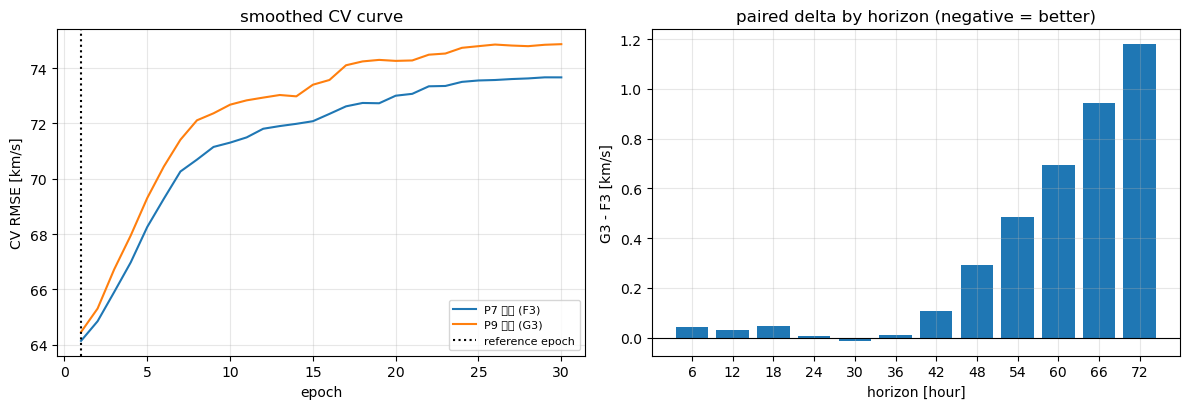

In [10]:
QUICK_PAIR = [("P7 기준 (F3)", "F3"), ("P9 전체 (G3)", "G3")]

VERBOSE_MODEL = False
RESULTS, ACTIVE_SEEDS = [], QUICK_SEEDS
for label, code_name in QUICK_PAIR:
    settings = config_at(code_name)
    configure(**settings)
    print(f"\n=== {label} ===  ch_seq {CH_SEQ_DIM} / 탄도 {BALLISTIC_DIM} / "
          f"gather {N_GATHER} / 플래그 {FLAG_DIM if USE_TRANSIT_FLAGS else 0}", flush=True)
    curves = run_cv(code_name, LADDER_FOLDS_LIST, seeds=QUICK_SEEDS,
                    signature=settings_signature(settings))
    RESULTS.append({"label": label, "settings": settings, "curves": curves})
VERBOSE_MODEL = True

# [B] 기준 epoch 은 기준 config(F3) 의 평활 곡선에서 한 번만 고른다
REFERENCE_EPOCH = int(np.argmin(
    smooth_curve(RESULTS[0]["curves"].mean(axis=(0, 1))).mean(axis=1)))
base_score = score_at(RESULTS[0]["curves"], REFERENCE_EPOCH)
variant_score = score_at(RESULTS[1]["curves"], REFERENCE_EPOCH)

overall = paired_delta(RESULTS[0]["curves"], RESULTS[1]["curves"], REFERENCE_EPOCH)
long_h = paired_delta(RESULTS[0]["curves"], RESULTS[1]["curves"], REFERENCE_EPOCH,
                      columns=slice(6, 12))
short_h = paired_delta(RESULTS[0]["curves"], RESULTS[1]["curves"], REFERENCE_EPOCH,
                       columns=slice(0, 6))

print("\n" + "=" * 72)
print(f"기준 epoch {REFERENCE_EPOCH + 1} | 대응 쌍 {overall['n']}개 "
      f"({len(LADDER_FOLDS_LIST)}폴드 x {len(QUICK_SEEDS)}시드)")
print(f"  P7 기준 (F3) CV {base_score['cv']:.3f}")
print(f"  P9 전체 (G3) CV {variant_score['cv']:.3f}")
print("-" * 72)
for name, result in [("전체", overall), ("6-36h", short_h), ("42-72h", long_h)]:
    print(f"  {name:7s} dCV {result['delta']:+7.3f}  paired_se {result['se']:.3f}  "
          f"({NOISE_SIGMA:.0f}se {NOISE_SIGMA * result['se']:.3f})  "
          f"-> {verdict(result['delta'], result['se'])}")
print("-" * 72)
print(f"  paired_se {overall['se']:.3f} vs unpaired_se {overall['unpaired_se']:.3f} "
      f"(x{overall['unpaired_se'] / max(overall['se'], 1e-9):.1f} 절약)")
print(f"  쌍별 차이: {np.round(overall['per_pair'], 2).tolist()}")
print("=" * 72)

quick = pd.DataFrame({
    "horizon": HORIZONS,
    "F3_P7": base_score["per_horizon"].round(2),
    "G3_P9": variant_score["per_horizon"].round(2),
    "delta": (variant_score["per_horizon"] - base_score["per_horizon"]).round(2),
})
print(quick.to_string(index=False))
quick.to_csv(OUTPUT_DIR / "quick_ab.csv", index=False)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for result in RESULTS:
    axes[0].plot(np.arange(1, CV_EPOCHS + 1),
                 smooth_curve(result["curves"].mean(axis=(0, 1))).mean(axis=1),
                 label=result["label"])
axes[0].axvline(REFERENCE_EPOCH + 1, color="k", linestyle=":", label="reference epoch")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CV RMSE [km/s]")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_title("smoothed CV curve")
axes[1].bar(np.arange(12), variant_score["per_horizon"] - base_score["per_horizon"])
axes[1].axhline(0, color="k", linewidth=0.8)
axes[1].set_xticks(np.arange(12)); axes[1].set_xticklabels(HORIZONS)
axes[1].set_xlabel("horizon [hour]"); axes[1].set_ylabel("G3 - F3 [km/s]")
axes[1].grid(alpha=0.3); axes[1].set_title("paired delta by horizon (negative = better)")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "quick_ab.png", dpi=140); plt.show()

### 전체 사다리 (선택) — 귀속이 필요할 때만

A/B 에서 개선이 확인됐고 **어느 변경이 기여했는지** 알고 싶을 때만 `RUN_FULL_LADDER = True`.
제출에는 필요 없다. 중단해도 끝난 칸은 캐시에 남아 다시 안 돈다.

In [11]:
LADDER_RUNGS = slice(None)          # 시간이 부족하면 slice(0, 8) 등으로 자른다

if RUN_FULL_LADDER:
    rungs = ABLATION_LADDER[LADDER_RUNGS]
    total = len(rungs) * len(LADDER_FOLDS_LIST) * len(CV_SEEDS)
    print(f"사다리 {len(rungs)}칸 x {len(LADDER_FOLDS_LIST)}폴드 x {len(CV_SEEDS)}시드 "
          f"= 학습 {total}회, 약 {total * RUN_MINUTES:.0f}분")
    VERBOSE_MODEL = False
    RESULTS, ACTIVE_SEEDS, settings = [], CV_SEEDS, {}
    for label, overrides in rungs:
        settings.update(overrides)
        configure(**settings)
        print(f"\n=== {label} ===  ch_seq {CH_SEQ_DIM} / 탄도 {BALLISTIC_DIM} / "
              f"gather {N_GATHER} / 플래그 {FLAG_DIM if USE_TRANSIT_FLAGS else 0}",
              flush=True)
        curves = run_cv(label.split(".")[0], LADDER_FOLDS_LIST, seeds=CV_SEEDS,
                        signature=settings_signature(settings))
        RESULTS.append({"label": label, "settings": dict(settings), "curves": curves})
    VERBOSE_MODEL = True

    REFERENCE_EPOCH = int(np.argmin(
        smooth_curve(RESULTS[0]["curves"].mean(axis=(0, 1))).mean(axis=1)))
    print(f"\n[B] 기준 epoch = {REFERENCE_EPOCH + 1} (A0 에서 1회 선택)")
else:
    print("RUN_FULL_LADDER = False -> 건너뜀. 위 A/B 결과를 그대로 쓴다.")

RUN_FULL_LADDER = False -> 건너뜀. 위 A/B 결과를 그대로 쓴다.


### 요약 — 기준 epoch 하나로 비교, 2σ 규칙으로 판정

In [12]:
rows = []
for i, result in enumerate(RESULTS):
    score = score_at(result["curves"], REFERENCE_EPOCH)
    result["score"] = score
    row = {"config": result["label"], "CV": score["cv"],
           "fold_sd": score["fold_sd"], "seed_sd": score["seed_sd"],
           "6-36h": score["per_horizon"][:6].mean(),
           "42-72h": score["per_horizon"][6:].mean(),
           "72h": score["per_horizon"][-1],
           "own_best_ep": int(np.argmin(score["smoothed_mean"].mean(axis=1))) + 1}
    if i == 0:
        row.update({"dCV": np.nan, "paired_se": np.nan, "d42-72h": np.nan, "판정": "기준"})
    else:
        # 바로 앞 칸과 **같은 (fold, seed) 쌍**에서 비교한다
        overall = paired_delta(RESULTS[i - 1]["curves"], result["curves"], REFERENCE_EPOCH)
        longer = paired_delta(RESULTS[i - 1]["curves"], result["curves"], REFERENCE_EPOCH,
                              columns=slice(6, 12))
        row.update({"dCV": overall["delta"], "paired_se": overall["se"],
                    "d42-72h": longer["delta"],
                    "판정": verdict(overall["delta"], overall["se"])})
    rows.append(row)

summary = pd.DataFrame(rows)
print("=" * 104)
print(summary.round(3).to_string(index=False))
print("=" * 104)
print(f"dCV 는 바로 앞 칸과의 **대응** 차이다. |dCV| 가 {NOISE_SIGMA:.0f}*paired_se 를 "
      f"넘을 때만 개선/악화로 본다.")
print("own_best_ep 는 진단용이다 — config 비교에 쓰면 이중 선택 편향이 생긴다.")
if len(summary) > 1:
    print(f"[C] 시드 표준편차 평균 {summary.seed_sd.mean():.3f} / "
          f"폴드 표준편차 평균 {summary.fold_sd.mean():.3f} km/s")
summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)

if len(RESULTS) > 2:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    for result in RESULTS:
        axes[0].plot(np.arange(1, CV_EPOCHS + 1),
                     smooth_curve(result["curves"].mean(axis=(0, 1))).mean(axis=1),
                     label=result["label"].split(".")[0], linewidth=1.2)
    axes[0].axvline(REFERENCE_EPOCH + 1, color="k", linestyle=":")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CV RMSE [km/s]")
    axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)
    axes[0].set_title("[B] smoothed CV curve")
    axes[1].bar(np.arange(len(summary)), summary.dCV.fillna(0),
                yerr=NOISE_SIGMA * summary.paired_se.fillna(0), capsize=3)
    axes[1].axhline(0, color="k", linewidth=0.8)
    axes[1].set_xticks(np.arange(len(summary)))
    axes[1].set_xticklabels([c.split(".")[0] for c in summary.config], rotation=45)
    axes[1].set_ylabel("paired dCV [km/s]"); axes[1].grid(alpha=0.3)
    axes[1].set_title(f"per-rung paired delta (bar = {NOISE_SIGMA:.0f}*paired_se)")
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "ladder.png", dpi=140); plt.show()

    config     CV  fold_sd  seed_sd  6-36h  42-72h    72h  own_best_ep   dCV  paired_se  d42-72h   판정
P7 기준 (F3) 64.135    2.762    0.731 52.051  76.219 79.758            1   NaN        NaN      NaN   기준
P9 전체 (G3) 64.453    1.773    0.696 52.072  76.835 80.937            1 0.319      0.408    0.616 차이없음
dCV 는 바로 앞 칸과의 **대응** 차이다. |dCV| 가 2*paired_se 를 넘을 때만 개선/악화로 본다.
own_best_ep 는 진단용이다 — config 비교에 쓰면 이중 선택 편향이 생긴다.
[C] 시드 표준편차 평균 0.714 / 폴드 표준편차 평균 2.268 km/s


## 9. 채택 config 확정 검증

**요약표를 보고 사람이 고른다.** `ADOPTED_INDEX` 를 직접 지정할 것.
기본값은 "채택" 판정을 받은 마지막 칸이다 (전부 기각이면 A0).

확정 검증은 **전 폴드 × 전 시드**로 다시 돌린다. 사다리는 앞 3폴드만 썼기 때문이다.
여기서 정한 epoch 이 최종 학습 epoch 이 된다 — 채택된 config 에 대해서만 하는 **1회 선택**이다.

In [13]:
improved = [i for i, row in summary.iterrows() if row["판정"] == "개선"]
ADOPTED_INDEX = improved[-1] if improved else 0        # <- 필요하면 직접 바꿀 것

ADOPTED = RESULTS[ADOPTED_INDEX]
configure(**ADOPTED["settings"])
print(f"채택: {ADOPTED['label']}")
print(json.dumps({k: str(v) for k, v in ADOPTED["settings"].items()},
                 ensure_ascii=False, indent=2))

print(f"\n확정 검증: 전 {len(FOLDS)}폴드 x {len(ACTIVE_SEEDS)}시드 "
      f"(약 {len(FOLDS) * len(ACTIVE_SEEDS) * RUN_MINUTES:.0f}분)", flush=True)
VERBOSE_MODEL = False
FINAL_CURVES = run_cv("final", FOLDS, seeds=ACTIVE_SEEDS,
                      signature=settings_signature(ADOPTED["settings"]))
VERBOSE_MODEL = True

FINAL_SMOOTH = smooth_curve(FINAL_CURVES.mean(axis=(0, 1)))
FINAL_EPOCHS = int(np.argmin(FINAL_SMOOTH.mean(axis=1))) + 1
FINAL_SCORE = score_at(FINAL_CURVES, FINAL_EPOCHS - 1)

# 기준선은 CV 홀드아웃으로 실제 평가된 행에서만 낸다 (forward 모드에서는 부분집합이다)
held_out = np.unique(np.concatenate([evaluate for _, evaluate in FOLDS]))
train_persistence, train_climatology = baselines(train_targets[held_out],
                                                 train_wind[held_out])
report = pd.DataFrame({
    "horizon": HORIZONS,
    "cv_rmse": FINAL_SCORE["per_horizon"].round(2),
    "persistence": train_persistence.round(2),
    "climatology": train_climatology.round(2),
    "skill_vs_clim": (1 - FINAL_SCORE["per_horizon"] / train_climatology).round(3),
})
print(f"\n확정 CV {FINAL_SCORE['cv']:.3f} ± {FINAL_SCORE['se']:.3f} "
      f"(epoch {FINAL_EPOCHS})")
print(report.to_string(index=False))
print("\nskill_vs_clim 이 0 근처인 horizon 은 물리적 예측 한계다 — 그쪽은 더 파도 안 나온다.")
report.to_csv(OUTPUT_DIR / "cv_report.csv", index=False)

채택: P7 기준 (F3)
{
  "CH_GRID": "(6, 3)",
  "FOLD_LATITUDE": "True",
  "USE_LEVELS": "('dark0.45', 'bright')",
  "TRANSIT_SPEEDS": "(315.0, 345.0, 385.0, 435.0, 500.0, 600.0)",
  "BALLISTIC_SOURCE": "window",
  "BALLISTIC_LAT": "profile",
  "BALLISTIC_LON": "all",
  "BALLISTIC_OFFSETS": "(-4, -2, 0, 2)",
  "ADAPTIVE_AREA": "False",
  "ADAPTIVE_GATHER": "False",
  "USE_TRANSIT_FLAGS": "False",
  "USE_CH_GATHER": "True",
  "USE_BALLISTIC_WINDOW": "True",
  "CH_BIDIRECTIONAL": "True"
}

확정 검증: 전 5폴드 x 2시드 (약 39분)
  [final] 캐시 재사용 cv_final_79c1e205.npy (다시 돌리려면 파일을 지우거나 resume=False)

확정 CV 63.643 ± 0.763 (epoch 1)
 horizon  cv_rmse  persistence  climatology  skill_vs_clim
       6    26.78    26.480000    90.139999          0.703
      12    41.59    43.660000    90.160004          0.539
      18    51.53    56.889999    90.180000          0.429
      24    58.71    67.709999    90.150002          0.349
      30    63.94    76.809998    90.089996          0.290
      36    67.99    84.66000

## 10. 최종 학습

확정 검증이 정한 epoch 수로 **train 전체**에 대해 한 번 학습한다.
시드는 하나다 (판정에만 여러 시드를 썼고 제출 모델은 단일 모델이다).
validation 은 학습에 쓰지 않는다.

In [14]:
print(f"최종 학습: train 전체 {len(train_inputs):,} 샘플, {FINAL_EPOCHS} epoch")

FINAL_STATS = fit_stats(np.arange(len(train_inputs)))
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

final_loader = make_batcher(train_inputs, train_index_matrix, train_wind, train_wind_valid,
                            train_grid, FINAL_STATS, train_targets,
                            shuffle=True, seed=SEED, training=True)

model = build_model(FINAL_STATS)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# CV 와 동일한 LR 궤적을 쓰기 위해 T_max 는 CV_EPOCHS 로 둔다 (FINAL_EPOCHS 에서 멈출 뿐이다)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CV_EPOCHS)
scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

history = []
for epoch in range(FINAL_EPOCHS):
    started = time.perf_counter()
    model.train()
    squared_error, count = np.zeros(12), 0
    for batch in final_loader:
        moved = {k: batch[k].to(DEVICE, non_blocking=PIN_MEMORY)
                 for k in BATCH_KEYS + ("target",)}
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            residual = model(moved["wind_seq"], moved["wind_stats"], moved["ch_seq"],
                             moved["ballistic"], moved["gather_idx"], moved["flags"])
        prediction = residual.float() + moved["last_wind"].unsqueeze(1)
        loss = metric_loss(prediction, moved["target"])
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        error = (prediction.detach() - moved["target"]).double()
        squared_error += torch.sum(error ** 2, dim=0).cpu().numpy()
        count += error.shape[0]
    scheduler.step()
    train_rmse = float(np.sqrt(squared_error / count).mean())
    history.append({"epoch": epoch + 1, "train_rmse": train_rmse,
                    "seconds": time.perf_counter() - started})
    print(f"epoch {epoch + 1:03d} train {train_rmse:7.3f} "
          f"lr {optimizer.param_groups[0]['lr']:.2e} "
          f"{history[-1]['seconds']:5.1f}s", flush=True)

pd.DataFrame(history).to_csv(OUTPUT_DIR / "history.csv", index=False)

최종 학습: train 전체 9,607 샘플, 1 epoch
shared=288 head_input=464 (gather 96, ballistic 72, flags 0)
epoch 001 train  64.562 lr 2.99e-04   7.1s


## 11. Validation 확인 (판단용 아님) · Test 추론

validation 은 9월만 모인 구간이고 test 는 10~12월이다. 계절이 다르고 이미 여러 세대에 걸쳐
모델 선택에 소진됐다. **아래 표는 확인용이며 채택 판단은 8~9절의 CV 로 이미 끝났다.**

In [15]:
val_batcher = make_batcher(val_inputs, val_index_matrix, val_wind, val_wind_valid,
                           val_grid, FINAL_STATS, val_targets, shuffle=False)
val_prediction, val_ids = predict_with(model, val_batcher,
                                       FINAL_STATS["clip_low"], FINAL_STATS["clip_high"])
assert val_ids == val_inputs.sample_id.tolist()
val_score, val_per_horizon = official_rmse(val_targets, val_prediction)

P3_PER_HORIZON = np.array([28.35, 44.22, 53.62, 59.68, 64.32, 68.00,
                           70.64, 72.72, 74.44, 76.22, 78.20, 80.02])
comparison = pd.DataFrame({
    "horizon": HORIZONS, "P3": P3_PER_HORIZON, "P9": val_per_horizon.round(2),
    "delta": (val_per_horizon - P3_PER_HORIZON).round(2),
    "P9_cv": FINAL_SCORE["per_horizon"].round(2),
    "persistence": VAL_PERSISTENCE.round(2),
    "climatology": VAL_CLIMATOLOGY.round(2),
})
print(f"validation RMSE  P3 {P3_PER_HORIZON.mean():.3f} -> P9 {val_score:.3f} "
      f"(persistence {VAL_PERSISTENCE.mean():.3f}, climatology {VAL_CLIMATOLOGY.mean():.3f})")
print(comparison.to_string(index=False))
print("\n확인용 표다. validation 과 CV 가 크게 어긋나면 CV 쪽을 믿을 것 "
      "(validation 은 9월 단일 계절이고 이미 선택에 소진됐다).")
comparison.to_csv(OUTPUT_DIR / "validation_metrics.csv", index=False)

test_batcher = make_batcher(test_inputs, test_index_matrix, test_wind, test_wind_valid,
                            test_grid, FINAL_STATS, shuffle=False)
test_prediction, test_ids = predict_with(model, test_batcher,
                                         FINAL_STATS["clip_low"], FINAL_STATS["clip_high"])
assert test_ids == test_inputs.sample_id.tolist()
assert test_prediction.shape == (len(test_inputs), 12) and np.isfinite(test_prediction).all()

submission = pd.DataFrame(test_prediction, columns=TARGET_COLUMNS)
submission.insert(0, "sample_id", test_inputs.sample_id.tolist())
submission.to_csv(SUBMISSION_DIR / "submission.csv", index=False)

CONFIG = {"notebook": "P9", "ch_code_version": CH_CODE_VERSION,
          "fine_grid": list(FINE_GRID), "ch_grid": list(CH_GRID),
          "fold_latitude": FOLD_LATITUDE, "ch_cuts": list(CH_CUTS),
          "bright_cut": BRIGHT_CUT, "disk_margin": DISK_MARGIN,
          "per_frame_disk": PER_FRAME_DISK, "used_levels": list(USE_LEVELS),
          "transit_speeds": list(TRANSIT_SPEEDS),
          "reference_transit_hours": REFERENCE_TRANSIT_HOURS,
          "tau_scale": TAU_SCALE, "tau_ref_speed": TAU_REF_SPEED,
          "ballistic_offsets": list(BALLISTIC_OFFSETS),
          "gather_offsets": list(GATHER_OFFSETS),
          "ballistic_source": BALLISTIC_SOURCE, "ballistic_lat": BALLISTIC_LAT,
          "ballistic_lon": BALLISTIC_LON,
          "adaptive_area": ADAPTIVE_AREA, "adaptive_gather": ADAPTIVE_GATHER,
          "use_transit_flags": USE_TRANSIT_FLAGS, "flag_dim": FLAG_DIM,
          "use_ch_gather": USE_CH_GATHER, "use_ballistic_window": USE_BALLISTIC_WINDOW,
          "ch_bidirectional": CH_BIDIRECTIONAL, "gather_dim": GATHER_DIM,
          "fold_mode": FOLD_MODE, "cv_seeds": list(CV_SEEDS),
          "reference_epoch": REFERENCE_EPOCH + 1, "adopted": ADOPTED["label"],
          "seed": SEED, "epochs": FINAL_EPOCHS,
          "cv_rmse": FINAL_SCORE["cv"], "cv_se": FINAL_SCORE["se"], "val_rmse": val_score,
          "initialization": "random_from_scratch",
          **{k: (v.tolist() if isinstance(v, np.ndarray) else v)
             for k, v in FINAL_STATS.items()}}
torch.save({"model_state_dict": model.state_dict(), **CONFIG},
           SUBMISSION_DIR / "model.pth")
print(f"\nsubmission.csv {submission.shape}, model.pth 저장 완료")
print(submission[TARGET_COLUMNS].describe().loc[["mean", "std", "min", "max"]].round(1))

validation RMSE  P3 64.203 -> P9 66.978 (persistence 84.105, climatology 95.275)
 horizon    P3    P9  delta  P9_cv  persistence  climatology
       6 28.35 29.57   1.22  26.78    30.129999    94.190002
      12 44.22 46.13   1.91  41.59    49.610001    94.540001
      18 53.62 56.06   2.44  51.53    63.040001    94.769997
      24 59.68 62.65   2.97  58.71    73.260002    95.089996
      30 64.32 67.78   3.46  63.94    82.029999    95.199997
      36 68.00 71.67   3.67  67.99    89.150002    95.449997
      42 70.64 74.43   3.79  71.06    94.699997    95.570000
      48 72.72 76.29   3.57  73.39    99.059998    95.639999
      54 74.44 77.85   3.41  75.18   102.730003    95.669998
      60 76.22 79.21   2.99  76.63   105.949997    95.680000
      66 78.20 80.52   2.32  77.92   108.660004    95.709999
      72 80.02 81.58   1.56  78.99   110.930000    95.790001

확인용 표다. validation 과 CV 가 크게 어긋나면 CV 쪽을 믿을 것 (validation 은 9월 단일 계절이고 이미 선택에 소진됐다).

submission.csv (3868, 13), model.pth 저장 

## 12. 제출 점검

> ⚠️ `code.ipynb` 는 **수동 복사**다. 이 노트북을 저장(Ctrl+S)한 뒤 `submission/code.ipynb` 로 복사할 것.

In [16]:
EXPECTED_TEST_ROWS = 3868
ok = True
for name in ["code.ipynb", "model.pth", "submission.csv"]:
    path = SUBMISSION_DIR / name
    if path.exists():
        print(f"  {name:16s} {path.stat().st_size / 1024 ** 2:8.2f} MiB")
    else:
        print(f"  {name:16s} 없음"); ok = False

check = pd.read_csv(SUBMISSION_DIR / "submission.csv")
ok &= len(check) == EXPECTED_TEST_ROWS
ok &= list(check.columns) == ["sample_id"] + TARGET_COLUMNS
ok &= check.sample_id.tolist() == test_inputs.sample_id.tolist()
ok &= int(check.isna().sum().sum()) == 0
values = check[TARGET_COLUMNS].to_numpy()
ok &= bool((values >= FINAL_STATS["clip_low"] - 1e-6).all()
           and (values <= FINAL_STATS["clip_high"] + 1e-6).all())
print(f"\n행 수 {len(check)} / 결측 {int(check.isna().sum().sum())} / "
      f"값 범위 {values.min():.1f} ~ {values.max():.1f}")
print("최종:", "통과" if ok else "실패 — 위 항목 확인")

  code.ipynb           0.29 MiB
  model.pth            1.20 MiB
  submission.csv       0.88 MiB

행 수 3868 / 결측 0 / 값 범위 263.4 ~ 839.7
최종: 통과
